# LTI identification: redundant coordinates and canonical systems

A linear system can have many equivalent internal state coordinates. Consequently, learning all entries of its matrices can produce curved, disconnected parameter posteriors even when the data determine its input–output behavior well. Controller canonical coordinates remove this freedom and reduce the number of unknowns from $d^2+2d$ to $2d$ for a controllable SISO system.

[Canonical Bayesian Linear System Identification](https://arxiv.org/html/2507.11535v2) develops this identifiability argument and its consequences for inference and invariant quantities of interest. Here we reproduce the qualitative Experiment 0 comparison using basic Dynestyx building blocks: a NumPyro model, CD-Dynamax Kalman likelihood, Full + NUTS, and Canonical + AdaptiveMetropolis.

Everything needed to run this example is defined below. The default run uses five chains, 3,000 warmup steps, and 10,000 retained draws per chain. The figures and efficiency measurements come from this notebook's own fits.

In [1]:
%matplotlib inline
import os
import time
from functools import partial

import numpyro

numpyro.set_host_device_count(
    5
)  # Allow the five chains to run on separate CPU devices.
import arviz as az
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import numpyro.distributions as dist
import pandas as pd
import seaborn as sns
from IPython.display import display
from matplotlib.lines import Line2D
from numpyro.handlers import block, seed, substitute, trace
from numpyro.infer.util import log_density

import dynestyx as dsx
from dynestyx.inference.configs.filter import KFConfig
from dynestyx.inference.configs.mcmc import AdaptiveMetropolisConfig, NUTSConfig
from dynestyx.inference.configs.smoother import KFSmootherConfig
from dynestyx.inference.mcmc import MCMCInference

SMOKE = os.environ.get("LTI_SMOKE", "0") == "1"
CHAINS, WARMUP, DRAWS = (2, 100, 100) if SMOKE else (5, 3_000, 10_000)
COLORS = {"full": "#2463a6", "canonical": "#d77536"}
sns.set_theme(style="whitegrid", context="notebook", font_scale=0.9)
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "grid.alpha": 0.18,
    }
)

Matplotlib is building the font cache; this may take a moment.


## A true system and fresh observations

We use
$$x_{t+1}=Ax_t+Bu_t+w_t,\qquad y_t=Cx_t+v_t,$$
with $x_0\sim N(0,I)$, $w_t\sim N(0,0.09I)$, and $v_t\sim N(0,0.25)$. Controls are known. The control $u_t$ drives the transition **from** time $t$, and the initial observation measures $x_0$.

Change the three explicit true matrices to study another state dimension. The model and inference helpers infer $d$ from their shapes; observation and control dimensions remain one. Process/observation noise and zero feedthrough are known in both fitted models.

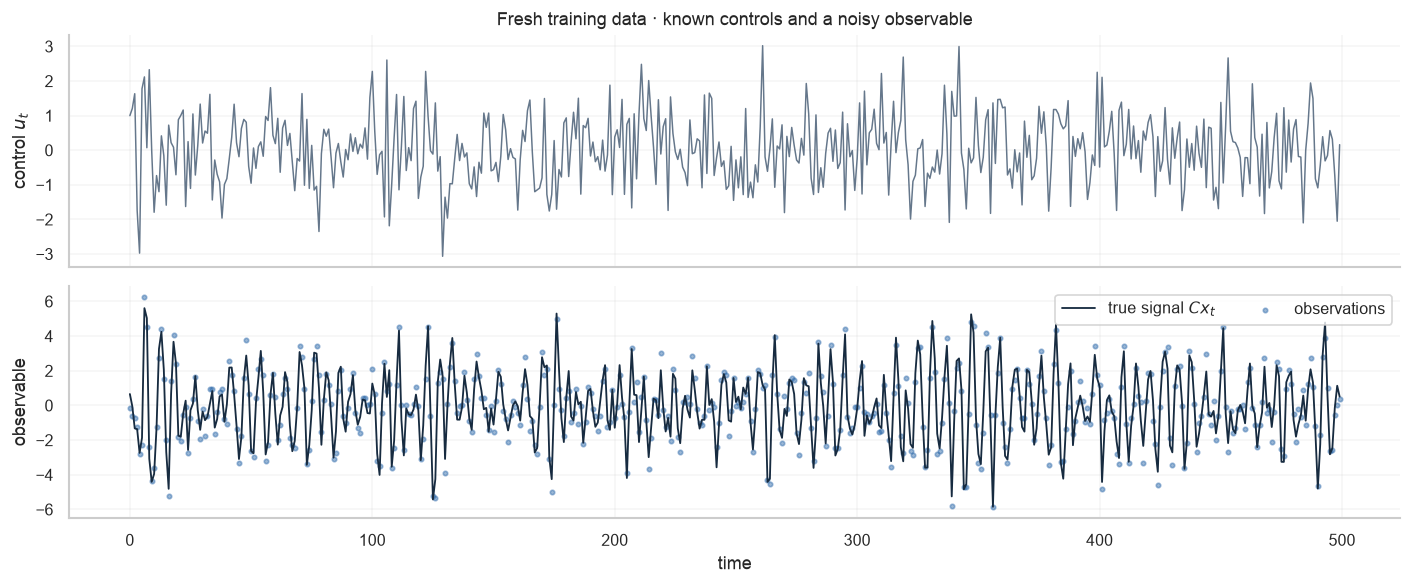

In [2]:
A_TRUE = jnp.array([[0.5, -0.93], [0.7, 0.3]])
B_TRUE = jnp.array([[0.2], [1.0]])
C_TRUE = jnp.array([[1.0, 0.5]])
STATE_DIM = A_TRUE.shape[0]
TRUE = {"A": A_TRUE, "B": B_TRUE, "C": C_TRUE}


def companion(alpha):
    """Last-row companion matrix, including batched coefficients."""
    d = alpha.shape[-1]
    A = jnp.zeros(alpha.shape[:-1] + (d, d), dtype=alpha.dtype)
    A = A.at[..., jnp.arange(d - 1), jnp.arange(1, d)].set(1.0)
    return A.at[..., -1, :].set(-alpha)


def matrices(parameters, form):
    if form == "full":
        return parameters["A"], parameters["B"], parameters["C"]
    d = parameters["alpha"].shape[-1]
    return companion(parameters["alpha"]), jnp.eye(d)[:, -1:], parameters["C"]


def system(parameters, form="full"):
    A, B, C = matrices(parameters, form)
    return dsx.LTI_discrete(
        A=A, B=B, H=C, Q=0.09 * jnp.eye(A.shape[-1]), R=jnp.array([[0.25]])
    )


def generate_data(key, length):
    input_key, simulation_key = jr.split(key)
    t = jnp.arange(length, dtype=A_TRUE.dtype)
    u = jr.normal(input_key, (length, 1))
    simulated = dsx.simulate(
        system(TRUE),
        rng_key=simulation_key,
        predict_times=t,
        ctrl_times=t,
        ctrl_values=u,
    )
    x, y = simulated.states[0], simulated.observations[0]
    return {"t": t, "u": u, "y": y, "signal": (x @ C_TRUE.T)[:, 0]}


train = generate_data(jr.PRNGKey(47), 500)
test = generate_data(jr.PRNGKey(48), 300)
CUTOFF = 200
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(train["t"], train["u"][:, 0], color="#65778b", lw=0.9)
axes[0].set(
    ylabel="control $u_t$",
    title="Fresh training data · known controls and a noisy observable",
)
axes[1].plot(
    train["t"], train["signal"], color="#172b40", lw=1.1, label="true signal $Cx_t$"
)
axes[1].scatter(
    train["t"],
    train["y"][:, 0],
    s=7,
    alpha=0.45,
    color=COLORS["full"],
    label="observations",
)
axes[1].set(xlabel="time", ylabel="observable")
axes[1].legend(ncol=2, loc="upper right")
fig.tight_layout()
plt.show()

## Two parameterizations, with the experimental priors preserved

**Full:** independent standard Gaussian priors on all entries of $A,B,C$, restricted to $|\operatorname{Re}\lambda_i(A)|<1$. This historical constraint is weaker than discrete-time stability, which requires $|\lambda_i|<1$.

**Canonical:** $A_c$ is the companion matrix with last row $-\alpha$, $B_c=e_d$, and $C_c$ is free. The coefficient prior below retains the source's real/complex root mixture, unit-disk support, and **positive** log-Vandermonde convention. It is the experiment's coefficient-space prior: the paper's eigenvalue-to-coefficient change of variables instead uses the reciprocal Vandermonde ([equations 15–16](https://arxiv.org/html/2507.11535v2#S4)). Ordinary Gaussian sample sites provide initialization; factors replace their density where necessary. The first entry of $C_c$ has the historical flat prior; all remaining entries have $N(0.5,1)$ priors. The unused independent noise coordinates have been integrated out.

Both dynamics-prior formulas extend to arbitrary fixed $d$. The full Gaussian restriction is proper. The canonical dynamics density is normalizable on bounded stable-coefficient space, but its mixture weights are historical choices, not dimension-independent real/complex probabilities. The flat first $C_c$ prior makes the complete canonical prior improper, already at $d=2$; posterior propriety and favorable geometry are not guaranteed for arbitrary data or higher dimensions. Near repeated roots, spectral computations can also become ill-conditioned.

We hold $Q$ and $P_0$ isotropic in **both** parameterizations. A general similarity transformation would also transform those covariances. Thus the full posterior projected to canonical coordinates and the native canonical fit have different stochastic models and priors; their densities need not agree exactly.

In [3]:
def polar_coefficient_logprior(alpha):
    eigenvalues = jnp.linalg.eigvals(companion(alpha))
    radius = jnp.abs(eigenvalues)
    real = jnp.abs(eigenvalues.imag) < 1e-12
    n_real, n_complex = real.sum(), (~real).sum()
    n_pairs = n_complex // 2
    real_lp = jnp.where(
        real, jnp.where((radius > 0) & (radius <= 1), jnp.log(radius), -jnp.inf), 0.0
    ).sum()
    valid_complex = (n_complex % 2 == 0) & jnp.all(real | (radius <= 1))
    complex_lp = jnp.where(valid_complex, -n_pairs * jnp.log(jnp.pi), -jnp.inf)
    differences = jnp.abs(eigenvalues[:, None] - eigenvalues[None, :])
    upper = jnp.triu(jnp.ones(differences.shape, dtype=bool), k=1)
    vandermonde = jnp.prod(jnp.where(upper, differences, 1.0))
    return (
        real_lp
        + complex_lp
        + n_real * jnp.log(0.707)
        + n_pairs * jnp.log(0.293)
        + jnp.log(vandermonde + 1e-12)
    )


def model(
    obs_times=None,
    obs_values=None,
    ctrl_times=None,
    ctrl_values=None,
    predict_times=None,
    *,
    form="full",
    state_dim=STATE_DIM,
):
    d = state_dim
    if form == "full":
        parameters = {
            name: numpyro.sample(name, dist.Normal(0, 1).expand(shape).to_event(2))
            for name, shape in {"A": (d, d), "B": (d, 1), "C": (1, d)}.items()
        }
        valid = jnp.all(jnp.abs(jnp.linalg.eigvals(parameters["A"]).real) < 1)
        numpyro.factor("real_part_support", jnp.where(valid, 0.0, -jnp.inf))
    else:
        reference = dist.Normal(0, 1).expand((d,)).to_event(1)
        alpha = numpyro.sample("alpha", reference)
        C = numpyro.sample("C", dist.Normal(0.5, 1).expand((1, d)).to_event(2))
        numpyro.factor(
            "coefficient_prior",
            polar_coefficient_logprior(alpha)
            - reference.log_prob(alpha)
            - jnp.log(2.0),
        )
        numpyro.factor("flat_first_C", -dist.Normal(0.5, 1).log_prob(C[0, 0]))
        parameters = {"alpha": alpha, "C": C}
    return dsx.sample(
        "system",
        system(parameters, form),
        obs_times=obs_times,
        obs_values=obs_values,
        ctrl_times=ctrl_times,
        ctrl_values=ctrl_values,
        predict_times=predict_times,
    )


def inference_model(*args, **kwargs):
    # Keep the likelihood factor, but do not collect state histories for every MCMC draw.
    with block(hide_fn=lambda message: message["type"] == "deterministic"):
        with dsx.Filter(KFConfig(filter_source="cd_dynamax")):
            return model(*args, **kwargs)

## Fit through one interface

The full model uses NumPyro NUTS; the canonical model uses Dynestyx's coordinatewise adaptive Metropolis sampler. Both consume the same NumPyro model and CD-Dynamax likelihood. Proposal scales adapt during warmup and remain fixed during retained sampling. Efficiency is measured rather than assumed.

All timings below include compilation, warmup, and every attempted chain. Raw samples remain in `results`; any diagnostic selection creates a separate view.

In [4]:
def fit(form, key, *, chains=CHAINS, warmup=WARMUP, draws=DRAWS):
    common = dict(num_chains=chains, num_warmup=warmup, num_samples=draws)
    config = (
        NUTSConfig(**common, mcmc_source="numpyro")
        if form == "full"
        else AdaptiveMetropolisConfig(**common)
    )
    inference = MCMCInference(config, partial(inference_model, form=form))
    started = time.perf_counter()
    samples = inference.run(
        key, train["t"], train["y"], ctrl_times=train["t"], ctrl_values=train["u"]
    )
    jax.block_until_ready(samples)
    seconds = time.perf_counter() - started
    if form == "full":  # NumPyro returns flattened chains; BlackJAX preserves them.
        samples = {
            name: value.reshape((chains, draws) + value.shape[1:])
            for name, value in samples.items()
        }
    print(
        f"{form}: {chains} chains × {draws:,} draws; total fit {seconds / 60:.1f} min",
        flush=True,
    )
    return {
        "samples": {k: np.asarray(v) for k, v in samples.items()},
        "diagnostics": {
            k: np.asarray(v) for k, v in inference.get_diagnostics().items()
        },
        "seconds": seconds,
    }

In [5]:
results = {}
results["full"] = fit("full", jr.PRNGKey(2026))

full: 5 chains × 10,000 draws; total fit 157.4 min


In [7]:
results["canonical"] = fit("canonical", jr.PRNGKey(2027))

canonical: 5 chains × 10,000 draws; total fit 1.2 min


In [9]:
def flatten_chains(samples):
    return {
        name: value.reshape((-1,) + value.shape[2:]) for name, value in samples.items()
    }


def parameter_array(samples, form):
    names = ("A", "B", "C") if form == "full" else ("alpha", "C")
    leading = samples[names[0]].shape[:2]
    values = np.concatenate(
        [samples[name].reshape(leading + (-1,)) for name in names], axis=-1
    )
    d = samples["C"].shape[-1]
    labels = (
        [f"A{i + 1}{j + 1}" for i in range(d) for j in range(d)]
        + [f"B{i + 1}" for i in range(d)]
        if form == "full"
        else [rf"$\alpha_{i}$" for i in range(d)]
    )
    return values, labels + [f"C{i + 1}" for i in range(d)]


def eigen_quantities(parameters, form):
    A, _, _ = matrices(parameters, form)
    A = np.asarray(A)
    eigenvalues = np.linalg.eigvals(A)
    return {
        "Re_min": eigenvalues.real.min(axis=-1),
        "Re_max": eigenvalues.real.max(axis=-1),
        "Im_abs_max": np.abs(eigenvalues.imag).max(axis=-1),
        "spectral_radius": np.abs(eigenvalues).max(axis=-1),
        "trace_A": np.trace(A, axis1=-2, axis2=-1),
        "det_A": np.linalg.det(A),
    }


def canonical_projection(parameters):
    """Deterministic SISO projection; batch axes are preserved."""
    A, B, C = (np.asarray(parameters[name]) for name in ("A", "B", "C"))
    d = A.shape[-1]
    roots = np.linalg.eigvals(A)
    coefficients = np.ones(roots.shape[:-1] + (1,), dtype=complex)
    for i in range(d):
        coefficients = np.pad(
            coefficients, [(0, 0)] * (coefficients.ndim - 1) + [(0, 1)]
        ) - roots[..., i, None] * np.pad(
            coefficients, [(0, 0)] * (coefficients.ndim - 1) + [(1, 0)]
        )
    alpha = coefficients[..., 1:][..., ::-1].real
    Ac = np.asarray(companion(jnp.asarray(alpha)))
    W, Wc = [], []
    b, bc = B, np.broadcast_to(np.eye(d)[:, -1:], B.shape).copy()
    for _ in range(d):
        W.append(b)
        Wc.append(bc)
        b, bc = A @ b, Ac @ bc
    W, Wc = np.concatenate(W, axis=-1), np.concatenate(Wc, axis=-1)
    if np.any(np.linalg.cond(W) > 1e10):
        raise ValueError(
            "Canonical projection requires a well-conditioned controllable realization"
        )
    T = np.linalg.solve(Wc.swapaxes(-1, -2), W.swapaxes(-1, -2)).swapaxes(-1, -2)
    return {"alpha": alpha, "C": C @ T}


def posterior_logdensities(samples, form):
    flat = {name: jnp.asarray(value) for name, value in flatten_chains(samples).items()}
    density = lambda p: log_density(
        partial(inference_model, form=form),
        (train["t"], train["y"]),
        dict(ctrl_times=train["t"], ctrl_values=train["u"]),
        p,
    )[0]
    return np.asarray(
        jax.jit(lambda p: jax.lax.map(density, p, batch_size=32))(flat)
    ).reshape(samples["C"].shape[:2])


def select_chains(result, form):
    samples = result["samples"]
    values, _ = parameter_array(samples, form)
    quantities = eigen_quantities(samples, form)
    checks = list(quantities.values())
    if form == "canonical":
        checks += [values[..., i] for i in range(values.shape[-1])]
    rows = []
    for c in range(len(values)):
        half = values.shape[1] // 2
        rhats = [
            float(az.rhat(np.stack([v[c, :half], v[c, -half:]]), method="rank"))
            for v in checks
            if np.ptp(v[c]) > 0
        ]
        within = max(rhats, default=np.inf)
        finite = (
            np.isfinite(values[c]).all() and np.isfinite(result["logdensity"][c]).all()
        )
        divergence_rate = float(
            result["diagnostics"].get("num_divergences", np.zeros(len(values)))[c]
        ) / len(values[c])
        retained = finite and within <= 1.05 and divergence_rate <= 0.01
        rows.append(
            dict(
                form=form,
                chain=c,
                retained=retained if not SMOKE else True,
                within_chain_rhat=within,
                divergence_rate=divergence_rate,
                mean_logdensity=result["logdensity"][c].mean(),
            )
        )
    table = pd.DataFrame(rows)
    keep = table.retained.to_numpy()
    if keep.sum() < 2:
        raise RuntimeError(
            f"Only {keep.sum()} {form} chains pass diagnostics; investigate before plotting"
        )
    return {k: v[keep] for k, v in samples.items()}, table


selected, maps, selection_tables = {}, {}, []
for form, result in results.items():
    result["logdensity"] = posterior_logdensities(result["samples"], form)
    selected[form], table = select_chains(result, form)
    selection_tables.append(table)
    retained_density = result["logdensity"][table.retained.to_numpy()]
    best = np.unravel_index(retained_density.argmax(), retained_density.shape)
    maps[form] = {name: value[best] for name, value in selected[form].items()}
display(pd.concat(selection_tables, ignore_index=True))
for form, result in results.items():
    print(form, result["diagnostics"])

,form,chain,retained,within_chain_rhat,divergence_rate,mean_logdensity
0,full,0,True,1.000270,0.0001,-564.509827
1,full,1,True,1.000190,0.0000,-564.395508
2,full,2,True,1.000595,0.0001,-564.468323
3,full,3,True,1.000229,0.0000,-564.465576
4,full,4,True,1.000228,0.0000,-564.437317
5,canonical,0,True,1.011668,0.0000,-561.520203
6,canonical,1,False,3.036336,0.0000,-1941.840454
7,canonical,2,True,1.017007,0.0000,-561.541626
8,canonical,3,True,1.002917,0.0000,-561.648987
9,canonical,4,True,1.011788,0.0000,-561.573486


full {'mean_acceptance_rate': array([0.92161393, 0.9135622 , 0.8594277 , 0.91490483, 0.9298162 ],
      dtype=float32), 'num_divergences': array([1, 0, 1, 0, 0], dtype=int32)}
canonical {'mean_acceptance_rate': array([[0.1208    , 0.0615    , 0.3477    , 0.45549998],
       [0.1191    , 0.0231    , 0.5294    , 0.8814    ],
       [0.1113    , 0.0478    , 0.11369999, 0.18259999],
       [0.1979    , 0.38939998, 0.22749999, 0.29009998],
       [0.14209999, 0.41939998, 0.57019997, 0.0346    ]], dtype=float32), 'final_proposal_scale': array([[2.7803743e-01, 5.9452045e-01, 3.6152929e-02, 2.6782757e-02],
       [7.1361400e-02, 3.6787957e-01, 1.5337288e-03, 3.0656223e-04],
       [3.1348631e-01, 7.5578344e-01, 1.2245662e-01, 7.7304907e-02],
       [1.6529906e-01, 7.9659209e-02, 6.1421350e-02, 4.6887811e-02],
       [2.3223653e-01, 7.5774133e-02, 1.8315699e-02, 4.0656978e-01]],
      dtype=float32)}


Chain exclusions use finite densities, at most 1% divergent transitions where applicable, and within-chain rank R-hat no larger than 1.05 (computed by comparing halves). Full chains are checked on invariant eigenvalue quantities, so different valid coordinate orientations are retained. Short smoke runs skip selection. These checks do not establish global mixing or rule out unvisited modes. All failed-chain time remains charged.

The markers called **MAP** below are the highest-density retained draws in each model's native coordinates. They are sampled approximations, not optimized modes. The projected full MAP is the image of that particular full draw, not a MAP estimate of the push-forward density.

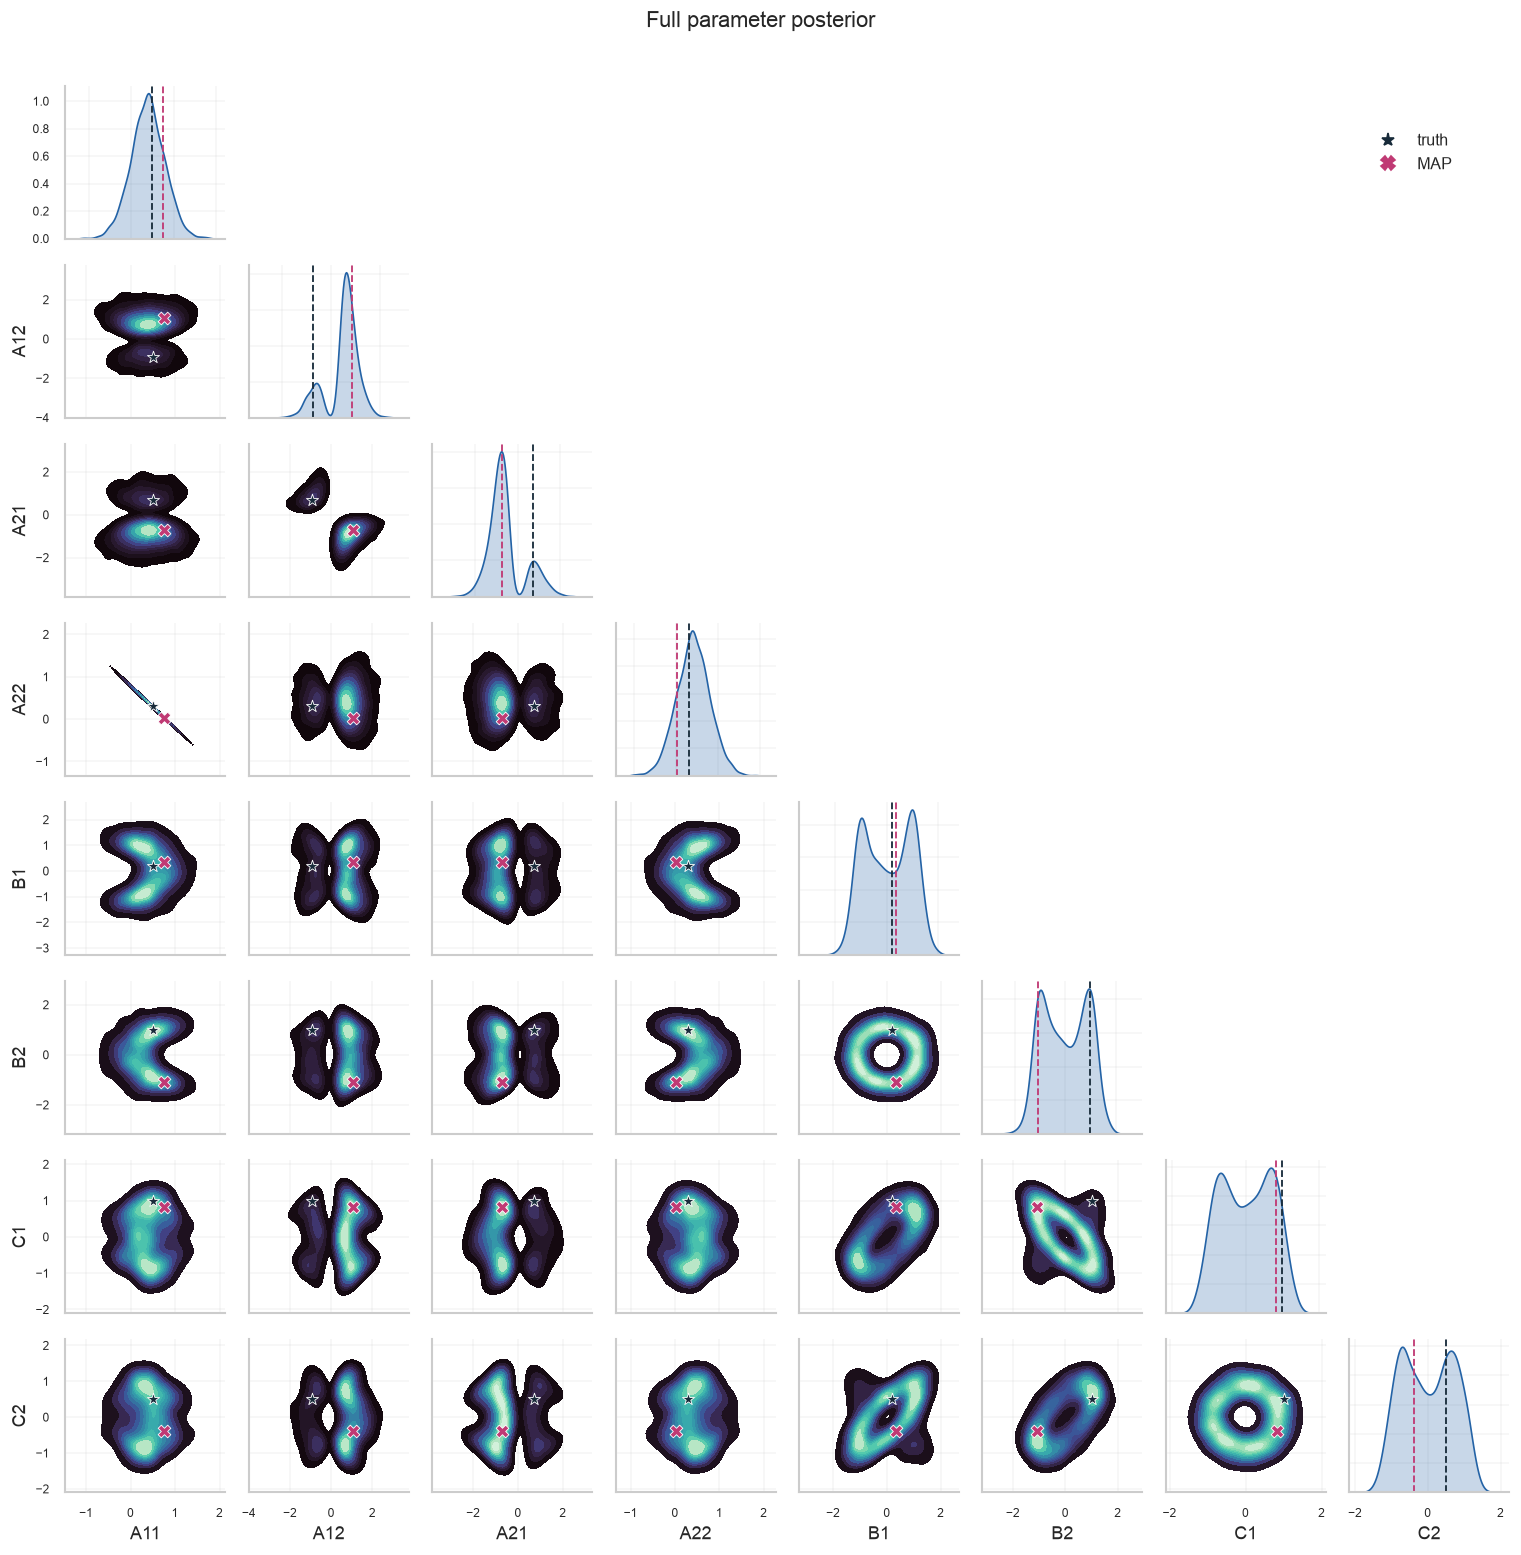

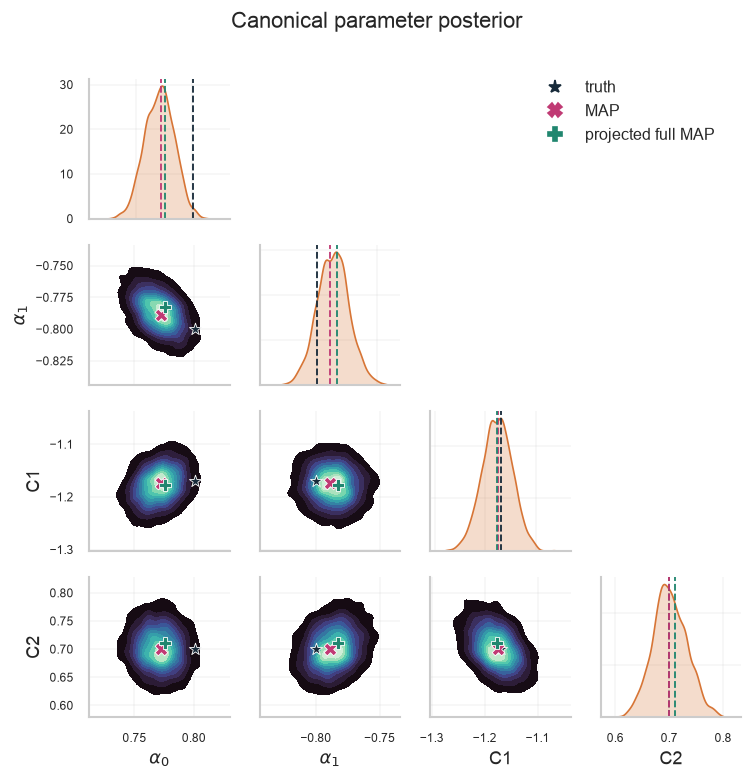

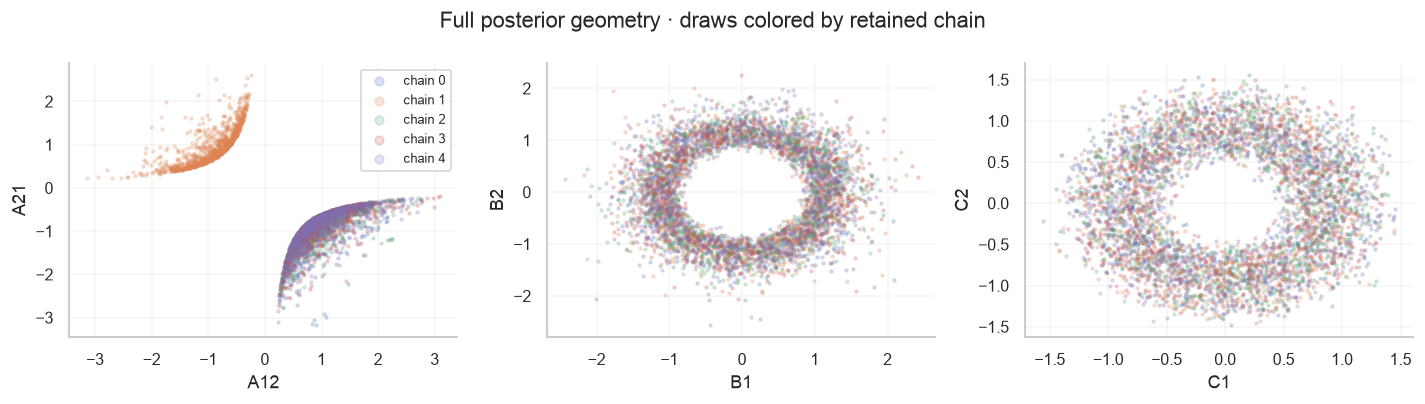

In [10]:
TRUTH_CANONICAL = canonical_projection(TRUE)
PROJECTED_FULL_MAP = canonical_projection(maps["full"])
MARKERS = {
    "truth": ("#182b3a", "*"),
    "MAP": ("#c03a74", "X"),
    "projected full MAP": ("#20866f", "P"),
}


def pairplot(values, labels, markers, *, title, color, columns=None):
    """Compact lower-triangle density plot; select columns for larger systems."""
    columns = list(range(len(labels))) if columns is None else list(columns)
    data = values.reshape(-1, values.shape[-1])
    data = data[np.linspace(0, len(data) - 1, min(3500, len(data)), dtype=int)][
        :, columns
    ]
    labels = [labels[i] for i in columns]
    n = len(labels)
    fig, axes = plt.subplots(
        n, n, figsize=(max(5, 1.6 * n), max(5, 1.6 * n)), squeeze=False
    )
    for i in range(n):
        for j in range(n):
            ax = axes[i, j]
            if j > i:
                ax.set_visible(False)
                continue
            if i == j:
                sns.kdeplot(
                    x=data[:, i], fill=True, color=color, ax=ax, warn_singular=False
                )
            else:
                sns.kdeplot(
                    x=data[:, j],
                    y=data[:, i],
                    fill=True,
                    cmap="mako",
                    levels=12,
                    thresh=0.04,
                    gridsize=90,
                    ax=ax,
                    warn_singular=False,
                )
            for name, point in markers.items():
                hue, symbol = MARKERS[name]
                point = np.asarray(point)[columns]
                if i == j:
                    ax.axvline(point[i], color=hue, ls="--", lw=1.1)
                else:
                    ax.scatter(
                        point[j],
                        point[i],
                        c=hue,
                        marker=symbol,
                        s=58,
                        edgecolor="white",
                        linewidth=0.5,
                        zorder=5,
                    )
            ax.set(
                xlabel=labels[j] if i == n - 1 else "",
                ylabel=labels[i] if j == 0 and i != j else "",
            )
            ax.tick_params(labelsize=7, labelbottom=i == n - 1, labelleft=j == 0)
    legend = [
        Line2D(
            [],
            [],
            marker=MARKERS[name][1],
            color=MARKERS[name][0],
            linestyle="None",
            markersize=8,
            label=name,
        )
        for name in markers
    ]
    fig.legend(
        handles=legend, loc="upper right", bbox_to_anchor=(0.96, 0.94), frameon=False
    )
    fig.suptitle(title, y=1.01)
    fig.tight_layout()
    plt.show()


for form in ("full", "canonical"):
    values, labels = parameter_array(selected[form], form)
    point_array = lambda p: parameter_array(
        {k: np.asarray(v)[None, None] for k, v in p.items()}, form
    )[0][0, 0]
    markers = {
        "truth": point_array(TRUE if form == "full" else TRUTH_CANONICAL),
        "MAP": point_array(maps[form]),
    }
    if form == "canonical":
        markers["projected full MAP"] = point_array(PROJECTED_FULL_MAP)
    pairplot(
        values,
        labels,
        markers,
        title=f"{form.capitalize()} parameter posterior",
        color=COLORS[form],
        columns=range(min(8, len(labels))),
    )

# Raw draws confirm that disconnected KDE regions are present in the sampled geometry.
if STATE_DIM >= 2:
    values, labels = parameter_array(selected["full"], "full")
    pairs = [
        (1, STATE_DIM),
        (STATE_DIM**2, STATE_DIM**2 + 1),
        (STATE_DIM**2 + STATE_DIM, STATE_DIM**2 + STATE_DIM + 1),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
    for ax, (i, j) in zip(axes, pairs):
        for c, chain in enumerate(values):
            ax.scatter(
                chain[::10, i], chain[::10, j], s=3, alpha=0.2, label=f"chain {c}"
            )
        ax.set(xlabel=labels[i], ylabel=labels[j])
    axes[0].legend(markerscale=3, fontsize=8)
    fig.suptitle("Full posterior geometry · draws colored by retained chain")
    fig.tight_layout()
    plt.show()

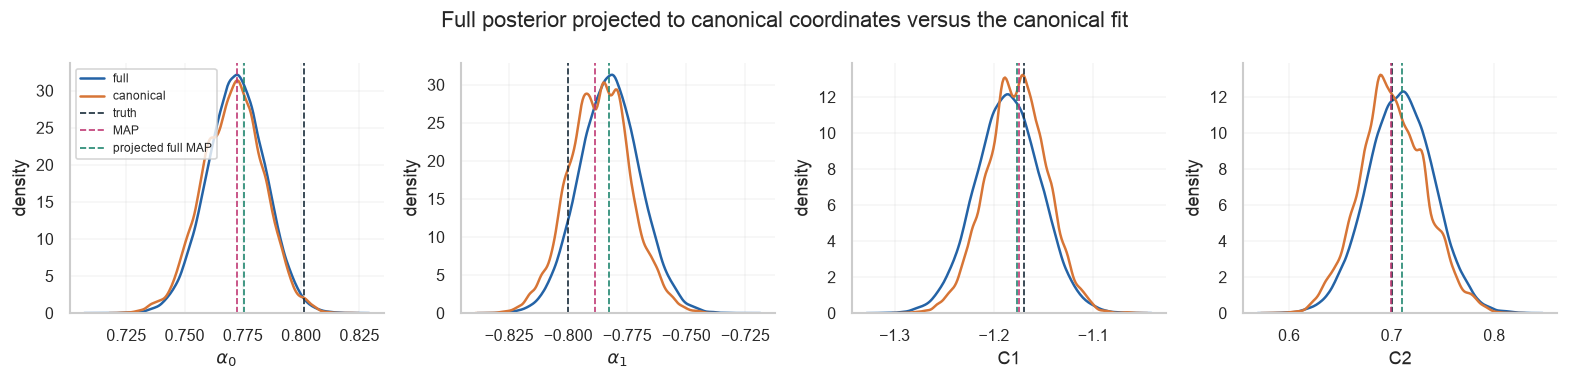

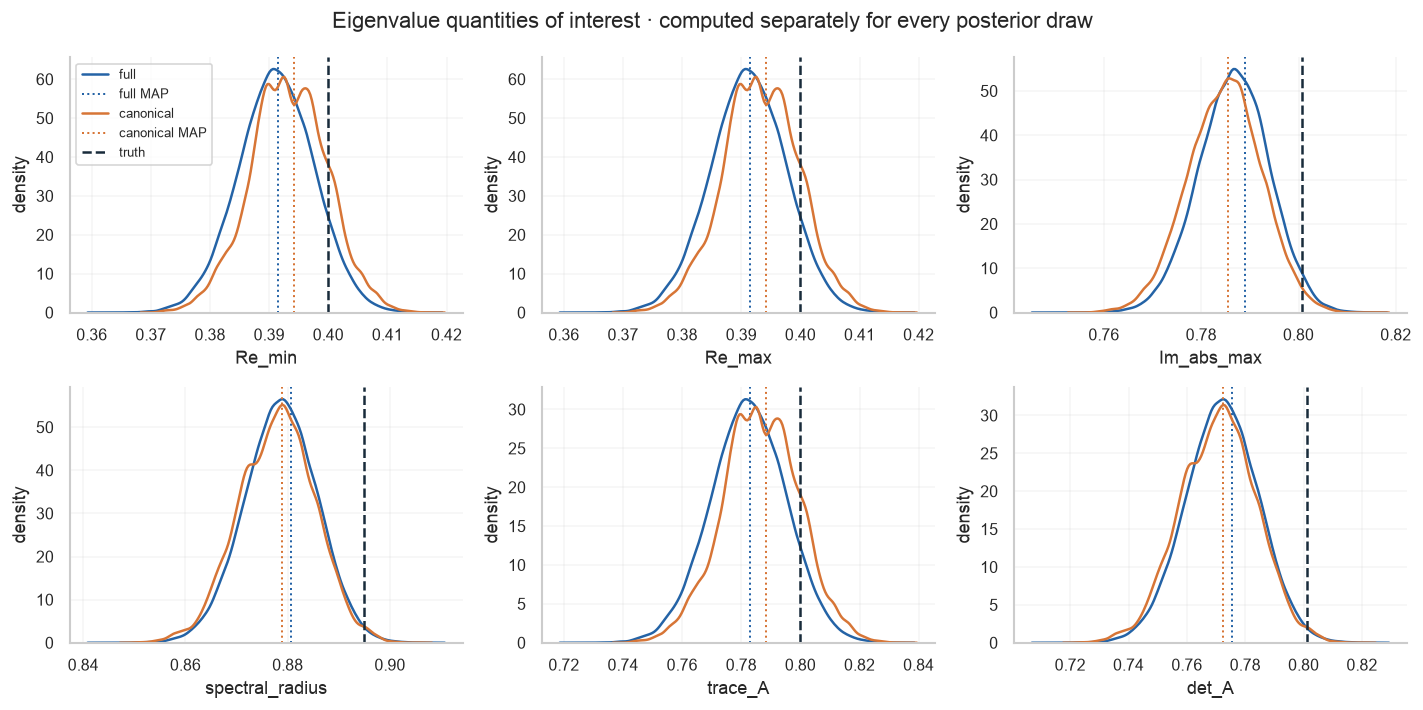

,form,quantity,mean,sd,rhat,ess_bulk,ess_per_second
0,full,A11,0.3859,0.4055,1.0005,9145.5903,0.9686
1,full,A12,0.5736,0.8793,1.4379,9.8753,0.0010
2,full,A21,-0.5747,0.8774,1.4379,9.8792,0.0010
3,full,A22,0.3966,0.4055,1.0005,9155.6044,0.9697
4,full,B1,0.0169,0.9090,1.0025,4307.7657,0.4562
5,full,B2,-0.0114,0.8979,1.0003,4247.5364,0.4499
6,full,C1,0.0112,0.6948,1.0005,4624.5610,0.4898
7,full,C2,0.0000,0.7083,1.0022,4642.1551,0.4917
8,full,Re_min,0.3912,0.0064,1.0000,53300.1345,5.6451
9,full,Re_max,0.3912,0.0064,1.0000,53300.1345,5.6451


form,canonical,full
quantity,,
Im_abs_max,69.090,5.713
Re_max,29.185,5.645
Re_min,29.185,5.645
det_A,45.351,5.747
spectral_radius,45.352,5.747
trace_A,29.185,5.645


In [11]:
common = {
    "full": canonical_projection(selected["full"]),
    "canonical": selected["canonical"],
}
common_labels = parameter_array(common["canonical"], "canonical")[1]
fig, axes = plt.subplots(
    1, len(common_labels), figsize=(3.3 * len(common_labels), 3.2), squeeze=False
)
for i, ax in enumerate(axes[0]):
    for form in common:
        values, _ = parameter_array(common[form], "canonical")
        sns.kdeplot(x=values[..., i].ravel(), color=COLORS[form], label=form, ax=ax)
    for name, point in {
        "truth": TRUTH_CANONICAL,
        "MAP": maps["canonical"],
        "projected full MAP": PROJECTED_FULL_MAP,
    }.items():
        v = parameter_array(
            {k: np.asarray(x)[None, None] for k, x in point.items()}, "canonical"
        )[0][0, 0, i]
        ax.axvline(v, color=MARKERS[name][0], ls="--", lw=1, label=name)
    ax.set(xlabel=common_labels[i], ylabel="density")
axes[0, 0].legend(fontsize=7)
fig.suptitle(
    "Full posterior projected to canonical coordinates versus the canonical fit"
)
fig.tight_layout()
plt.show()

quantities = {form: eigen_quantities(selected[form], form) for form in selected}
truth_qoi = eigen_quantities(TRUE, "full")
map_qoi = {form: eigen_quantities(maps[form], form) for form in maps}
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, name in zip(axes.flat, truth_qoi):
    for form in quantities:
        sns.kdeplot(
            x=quantities[form][name].ravel(), color=COLORS[form], label=form, ax=ax
        )
        ax.axvline(
            map_qoi[form][name], color=COLORS[form], ls=":", lw=1.2, label=f"{form} MAP"
        )
    ax.axvline(truth_qoi[name], color=MARKERS["truth"][0], ls="--", label="truth")
    ax.set(xlabel=name, ylabel="density")
axes[0, 0].legend(fontsize=8)
fig.suptitle(
    "Eigenvalue quantities of interest · computed separately for every posterior draw"
)
fig.tight_layout()
plt.show()

rows = []
for form in selected:
    values, labels = parameter_array(selected[form], form)
    variables = dict(zip(labels, np.moveaxis(values, -1, 0))) | quantities[form]
    for name, value in variables.items():
        ess = float(az.ess(value, method="bulk"))
        rows.append(
            dict(
                form=form,
                quantity=name,
                mean=value.mean(),
                sd=value.std(),
                rhat=float(az.rhat(value, method="rank")),
                ess_bulk=ess,
                ess_per_second=ess / results[form]["seconds"],
            )
        )
summary = pd.DataFrame(rows)
display(summary.round(4))
display(
    summary[summary.quantity.isin(truth_qoi)]
    .pivot(index="quantity", columns="form", values="ess_per_second")
    .round(3)
)

## A new trajectory: observable smoothing, then forecasting

The training parameter posterior stays fixed. For each fitted system we condition its **latent state** on the first 200 observations of a new trajectory, then forecast the next 100 steps using known future controls. Ensemble parameter draws keep equal weights: this evaluates the learned systems on another trajectory rather than updating their parameter distributions with the new observations.

The three panels compare **native parameter means**, **approximate MAP draws**, and **100-draw posterior ensembles**. Averaging the full matrices can cancel equivalent realizations; averaging predictions over complete draws avoids that cancellation. A full-model mean also depends on the sampled mixture of disconnected components when chains do not cross between them.

Dynestyx's Kalman smoother returns state means/covariances. We project those through $C$ to obtain smoothed **signal** marginals $Cx_t$ (without adding measurement noise). Future simulations include latent, process, and observation noise. The ensemble adds parameter uncertainty. These are pointwise 90% intervals; the noise interpretation changes at the forecast boundary.

Posterior-mean parameters / full: 1 parameter values


Approximate MAP parameters / full: 1 parameter values


Posterior ensemble / full: 100 parameter values


Posterior-mean parameters / canonical: 1 parameter values


Approximate MAP parameters / canonical: 1 parameter values


Posterior ensemble / canonical: 100 parameter values


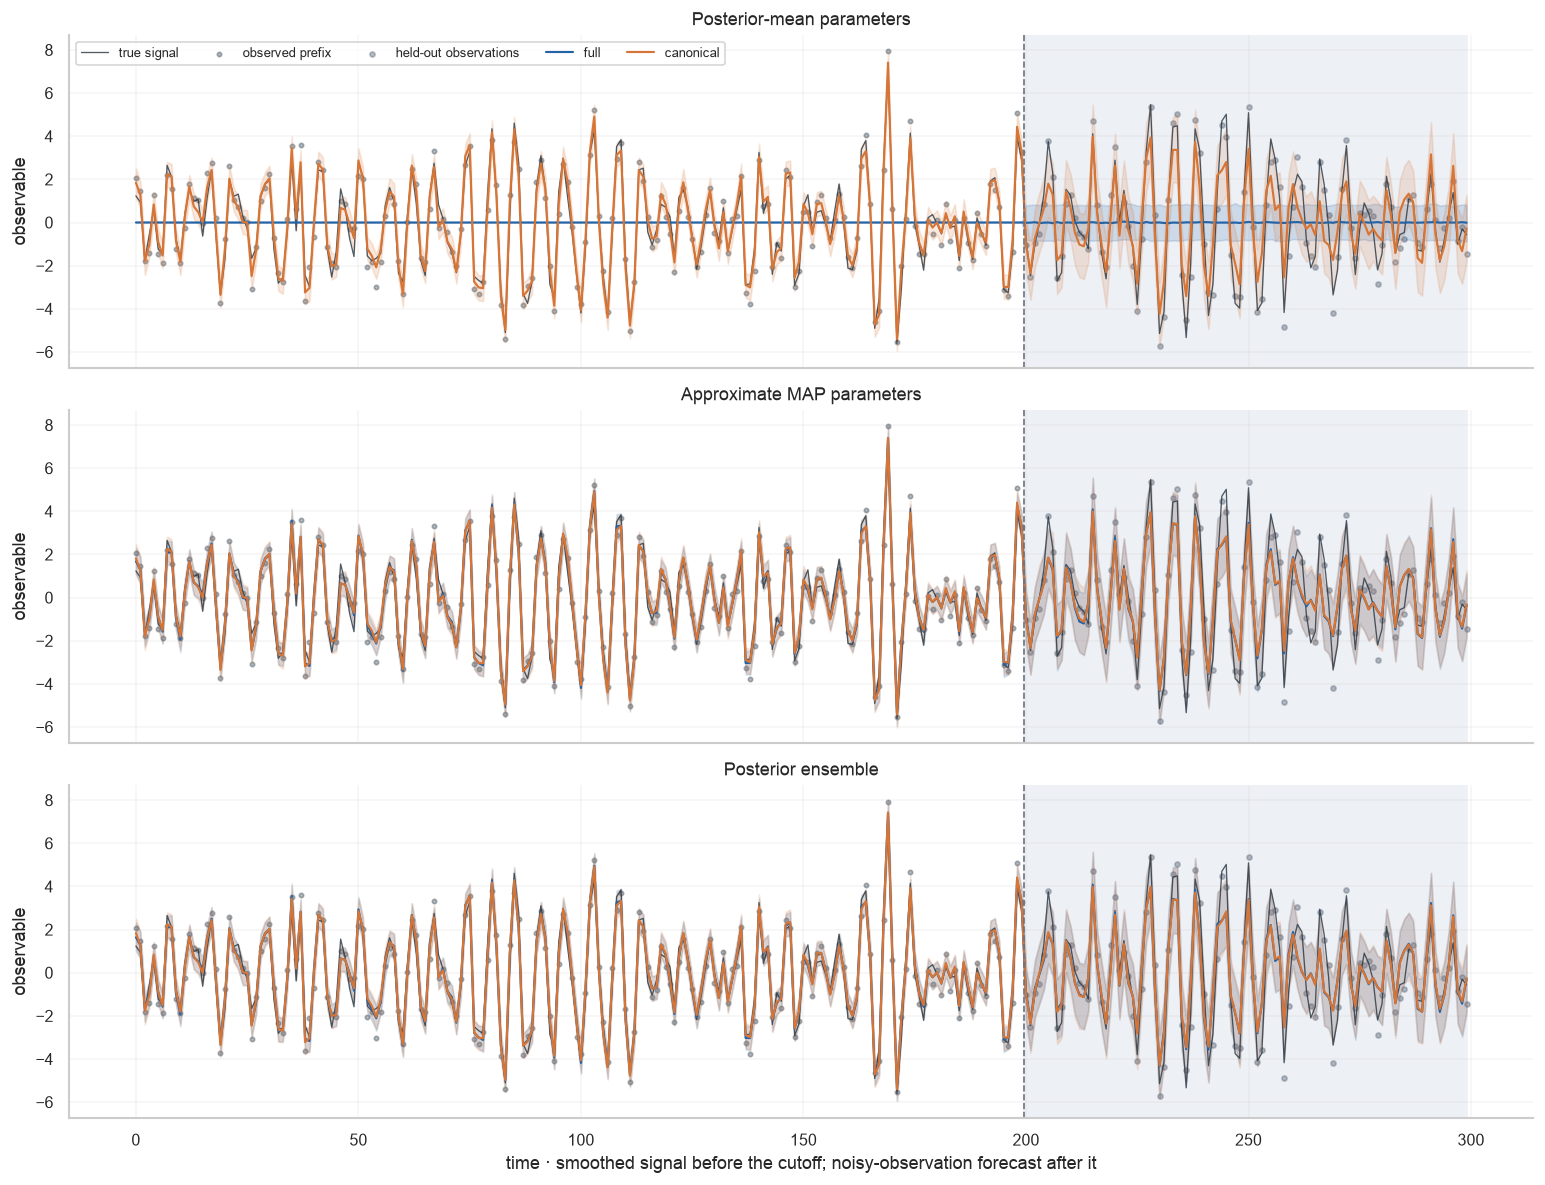

In [12]:
def smooth_and_forecast(parameters, form, key, *, n_simulations=10):
    """One system, conditioned only on the evaluation prefix."""
    conditioned = substitute(
        partial(model, form=form, state_dim=parameters["C"].shape[-1]), data=parameters
    )
    with seed(rng_seed=key), dsx.DiscreteTimeSimulator(n_simulations=n_simulations):
        with dsx.Smoother(KFSmootherConfig(filter_source="cd_dynamax")):
            output = trace(conditioned).get_trace(
                obs_times=test["t"][:CUTOFF],
                obs_values=test["y"][:CUTOFF],
                ctrl_times=test["t"],
                ctrl_values=test["u"],
                predict_times=test["t"][CUTOFF - 1 :],
            )
    C = jnp.asarray(parameters["C"])[0]
    mean = output["system_smoothed_states_mean"]["value"] @ C
    covariance = output["system_smoothed_states_cov"]["value"]
    variance = jnp.einsum("i,tij,j->t", C, covariance, C)
    future = output["system_predicted_observations"]["value"][:, 1:, 0]
    # Marginal signal draws give pointwise mixture intervals; temporal paths are unnecessary here.
    noise = jr.normal(jr.fold_in(key, 1), (n_simulations, CUTOFF))
    signal = mean + noise * jnp.sqrt(jnp.maximum(variance, 0))
    return jnp.concatenate([signal, future], axis=1)


def forecast_distribution(parameters, form, key, *, n_simulations):
    keys = jr.split(key, parameters["C"].shape[0])
    draws = jax.jit(
        jax.vmap(
            lambda p, k: smooth_and_forecast(p, form, k, n_simulations=n_simulations)
        )
    )(parameters, keys)
    return np.asarray(draws).reshape(-1, len(test["t"]))


predictions = {}
for form in selected:
    flat = flatten_chains(selected[form])
    count = len(flat["C"])
    # Stratification across the concatenated retained chains gives each chain approximately equal representation.
    index = np.linspace(0, count - 1, min(100, count), dtype=int)
    ensembles = {
        "Posterior-mean parameters": {
            k: v.mean(axis=0, keepdims=True) for k, v in flat.items()
        },
        "Approximate MAP parameters": {k: v[None] for k, v in maps[form].items()},
        "Posterior ensemble": {k: v[index] for k, v in flat.items()},
    }
    for panel, parameters in ensembles.items():
        n_simulations = 10 if panel == "Posterior ensemble" else 1000
        predictions[panel, form] = forecast_distribution(
            {k: jnp.asarray(v) for k, v in parameters.items()},
            form,
            jr.PRNGKey(3000 + len(predictions)),
            n_simulations=n_simulations,
        )
        print(f"{panel} / {form}: {len(parameters['C'])} parameter values", flush=True)

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True, sharey=True)
for ax, panel in zip(axes, ensembles):
    ax.axvspan(CUTOFF - 0.5, len(test["t"]) - 1, color="#edf0f5", zorder=0)
    ax.plot(
        test["t"],
        test["signal"],
        color="#253440",
        lw=0.8,
        alpha=0.8,
        label="true signal",
    )
    ax.scatter(
        test["t"][:CUTOFF],
        test["y"][:CUTOFF, 0],
        s=7,
        c="#253440",
        alpha=0.35,
        label="observed prefix",
    )
    ax.scatter(
        test["t"][CUTOFF:],
        test["y"][CUTOFF:, 0],
        s=9,
        c="#778391",
        alpha=0.55,
        label="held-out observations",
    )
    for form in selected:
        draws = predictions[panel, form]
        lo, hi = np.quantile(draws, [0.05, 0.95], axis=0)
        ax.fill_between(test["t"], lo, hi, color=COLORS[form], alpha=0.16)
        ax.plot(test["t"], draws.mean(axis=0), color=COLORS[form], lw=1.3, label=form)
    ax.axvline(CUTOFF - 0.5, c="#687482", ls="--", lw=1)
    ax.set(title=panel, ylabel="observable")
axes[0].legend(ncol=5, fontsize=8, loc="upper left")
axes[-1].set_xlabel(
    "time · smoothed signal before the cutoff; noisy-observation forecast after it"
)
fig.tight_layout()
plt.show()

In [13]:
def forecast_scores(draws, observed):
    mean = draws.mean(axis=0)
    lo, hi = np.quantile(draws, [0.05, 0.95], axis=0)
    ordered = np.sort(draws, axis=0)
    n = len(draws)
    # Empirical CRPS: E|Y-y| - 1/2 E|Y-Y'|, evaluated without a quadratic pair matrix.
    weights = (2 * np.arange(1, n + 1) - n - 1)[:, None]
    crps = (
        np.abs(draws - observed).mean(axis=0) - (weights * ordered).sum(axis=0) / n**2
    )
    return dict(
        RMSE=np.sqrt(np.mean((mean - observed) ** 2)),
        CRPS=crps.mean(),
        coverage_90=np.mean((observed >= lo) & (observed <= hi)),
        interval_width=(hi - lo).mean(),
    )


scores = pd.DataFrame(
    [
        dict(
            panel=panel,
            form=form,
            **forecast_scores(draws[:, CUTOFF:], np.asarray(test["y"])[CUTOFF:, 0]),
        )
        for (panel, form), draws in predictions.items()
    ]
)
display(scores.round(4))

,panel,form,RMSE,CRPS,coverage_90,interval_width
0,Posterior-mean parameters,full,2.4613,1.7140,0.25,1.6346
1,Approximate MAP parameters,full,1.1680,0.6799,0.76,2.9152
2,Posterior ensemble,full,1.1929,0.6958,0.72,2.9416
3,Posterior-mean parameters,canonical,1.1754,0.6829,0.80,3.0336
4,Approximate MAP parameters,canonical,1.1646,0.6737,0.80,3.0313
5,Posterior ensemble,canonical,1.1704,0.6759,0.80,3.0792


## Reading the comparison

Use the raw scatter and parameter densities to assess non-identifiability, and the per-draw eigenvalue quantities to assess identified dynamics. A high raw-coordinate R-hat can reflect chains trapped in different valid orientations even when invariant quantities mix well; it must remain visible. Canonical chain selection does not prove that other posterior modes are absent.

The timing table compares the two parameterization–sampler combinations. It does not isolate the effect of canonicalization from the change of algorithm. The forecast table compares the previously learned systems on the same held-out observations, without parameter refitting. Agreement of invariant quantities or predictions is compatible with very different parameter posteriors.

In the displayed run, all five Full chains pass the invariant checks and retain both disconnected orientations (four chains in one, one in the other). Their off-diagonal matrix entries have rank R-hat about 1.44, so the raw-coordinate samples do not establish global mixing. Canonical chain 1 fails stationarity (within-chain R-hat 3.04); the other four have pooled R-hat below 1.004. Its raw draws and fit cost are preserved.

The spectral-radius ESS per total fit second is 5.75 for Full + NUTS and 45.35 for Canonical + AdaptiveMetropolis. The full native parameter mean forecasts poorly (held-out RMSE 2.46); the two posterior ensembles have similar RMSE (1.19 and 1.17). Their nominal 90% intervals cover 72% and 80% of the held-out observations on this trajectory, respectively, below the nominal coverage.